# **Detectia anomaliilor in date medicale folosind PyOD**

1. Descrierea problemei

Problema abordata consta in detectia automata a anomaliilor dintr-un set de date medicale ce contine masuratori hormonale si caracteristici clinice ale pacientilor. Anomaliile prezente in acest set de date sunt predominant anomalii locale, caracterizate prin observatii izolate fata de vecinii lor din spatiul caracteristicilor. Acestea nu formeaza clustere distincte, ci apar dispersate la periferia distributiei principale, ceea ce este specific datelor medicale reale, unde cazurile atipice sunt rare si eterogene.


# ALEGEREA SETULUI DE DATE

In [46]:
import kagglehub
import os
import pandas as pd

# 1. download dataset
path = kagglehub.dataset_download(
    "zhonglifr/thyroid-disease-unsupervised-anomaly-detection"
)

print("dataset downloaded in:", path)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError(f"no csv file found in {path}")

csv_file = csv_files[0]
full_csv_path = os.path.join(path, csv_file)

print("using csv file:", full_csv_path)

# 2. citire cu separator ;
df = pd.read_csv(full_csv_path, sep=";")

# 3. verificare
print(df.head())
print(df.shape)
print(df.dtypes)


Using Colab cache for faster access to the 'thyroid-disease-unsupervised-anomaly-detection' dataset.
dataset downloaded in: /kaggle/input/thyroid-disease-unsupervised-anomaly-detection
using csv file: /kaggle/input/thyroid-disease-unsupervised-anomaly-detection/annthyroid_unsupervised_anomaly_detection.csv
    Age  Sex  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  \
0  0.45  1.0           0.0                 0.0                        0.0   
1  0.61  0.0           0.0                 0.0                        0.0   
2  0.16  0.0           1.0                 0.0                        0.0   
3  0.85  0.0           0.0                 0.0                        0.0   
4  0.75  1.0           0.0                 0.0                        0.0   

   sick  pregnant  thyroid_surgery  I131_treatment  query_hypothyroid  ...  \
0   0.0       0.0              0.0             0.0                0.0  ...   
1   1.0       0.0              0.0             0.0                0.0  ..

# PREPROCESAREA, EXPLOATAREA SI VIZUALIZAREA DATELOR

2. Descrierea setului de date si explorarea lui

Setul de date utilizat contine informatii despre pacienti cu afectiuni ale tiroidei. Variabilele sunt de doua tipuri:


*   variabile numerice, precum: Age, TSH, T3, TT4, T4U si FTI;

*  variabile categorice binare, reprezentand prezenta sau absenta unor conditii medicale sau tratamente (de exemplu: sex, tratament cu tiroxina, interventii chirurgicale, etc.).







In etapa de preprocesare, datele au fost curatate prin eliminarea coloanelor inutile, conversia tuturor variabilelor in format numeric si tratarea valorilor lipsa. Ulterior, datele au fost standardizate folosind StandardScaler pentru a asigura comparabilitatea intre variabile cu scale diferite.
Explorarea datelor a fost realizata prin statistici descriptive si vizualizari grafice. Histogramele si boxplot-urile au evidentiat distributii asimetrice si valori extreme, in special pentru variabilele hormonale, sugerand prezenta unor observatii anormale. Matricea de corelatie a indicat relatii puternice intre anumite masuratori hormonale, precum TT4 si FTI, confirmand redundanta partiala a unor variabile.


valori lipsa dupa curatare:
 Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
dtype: int64
               Age          Sex  on_thyroxine  query_on_thyroxine  \
count  6916.000000  6916.000000   6916.000000         6916.000000   
mean      0.595098     0.307548      0.134615            0.015616   
std       6.189326     0.461512      0.341337            0.123993   
min       0.010000     0.000000

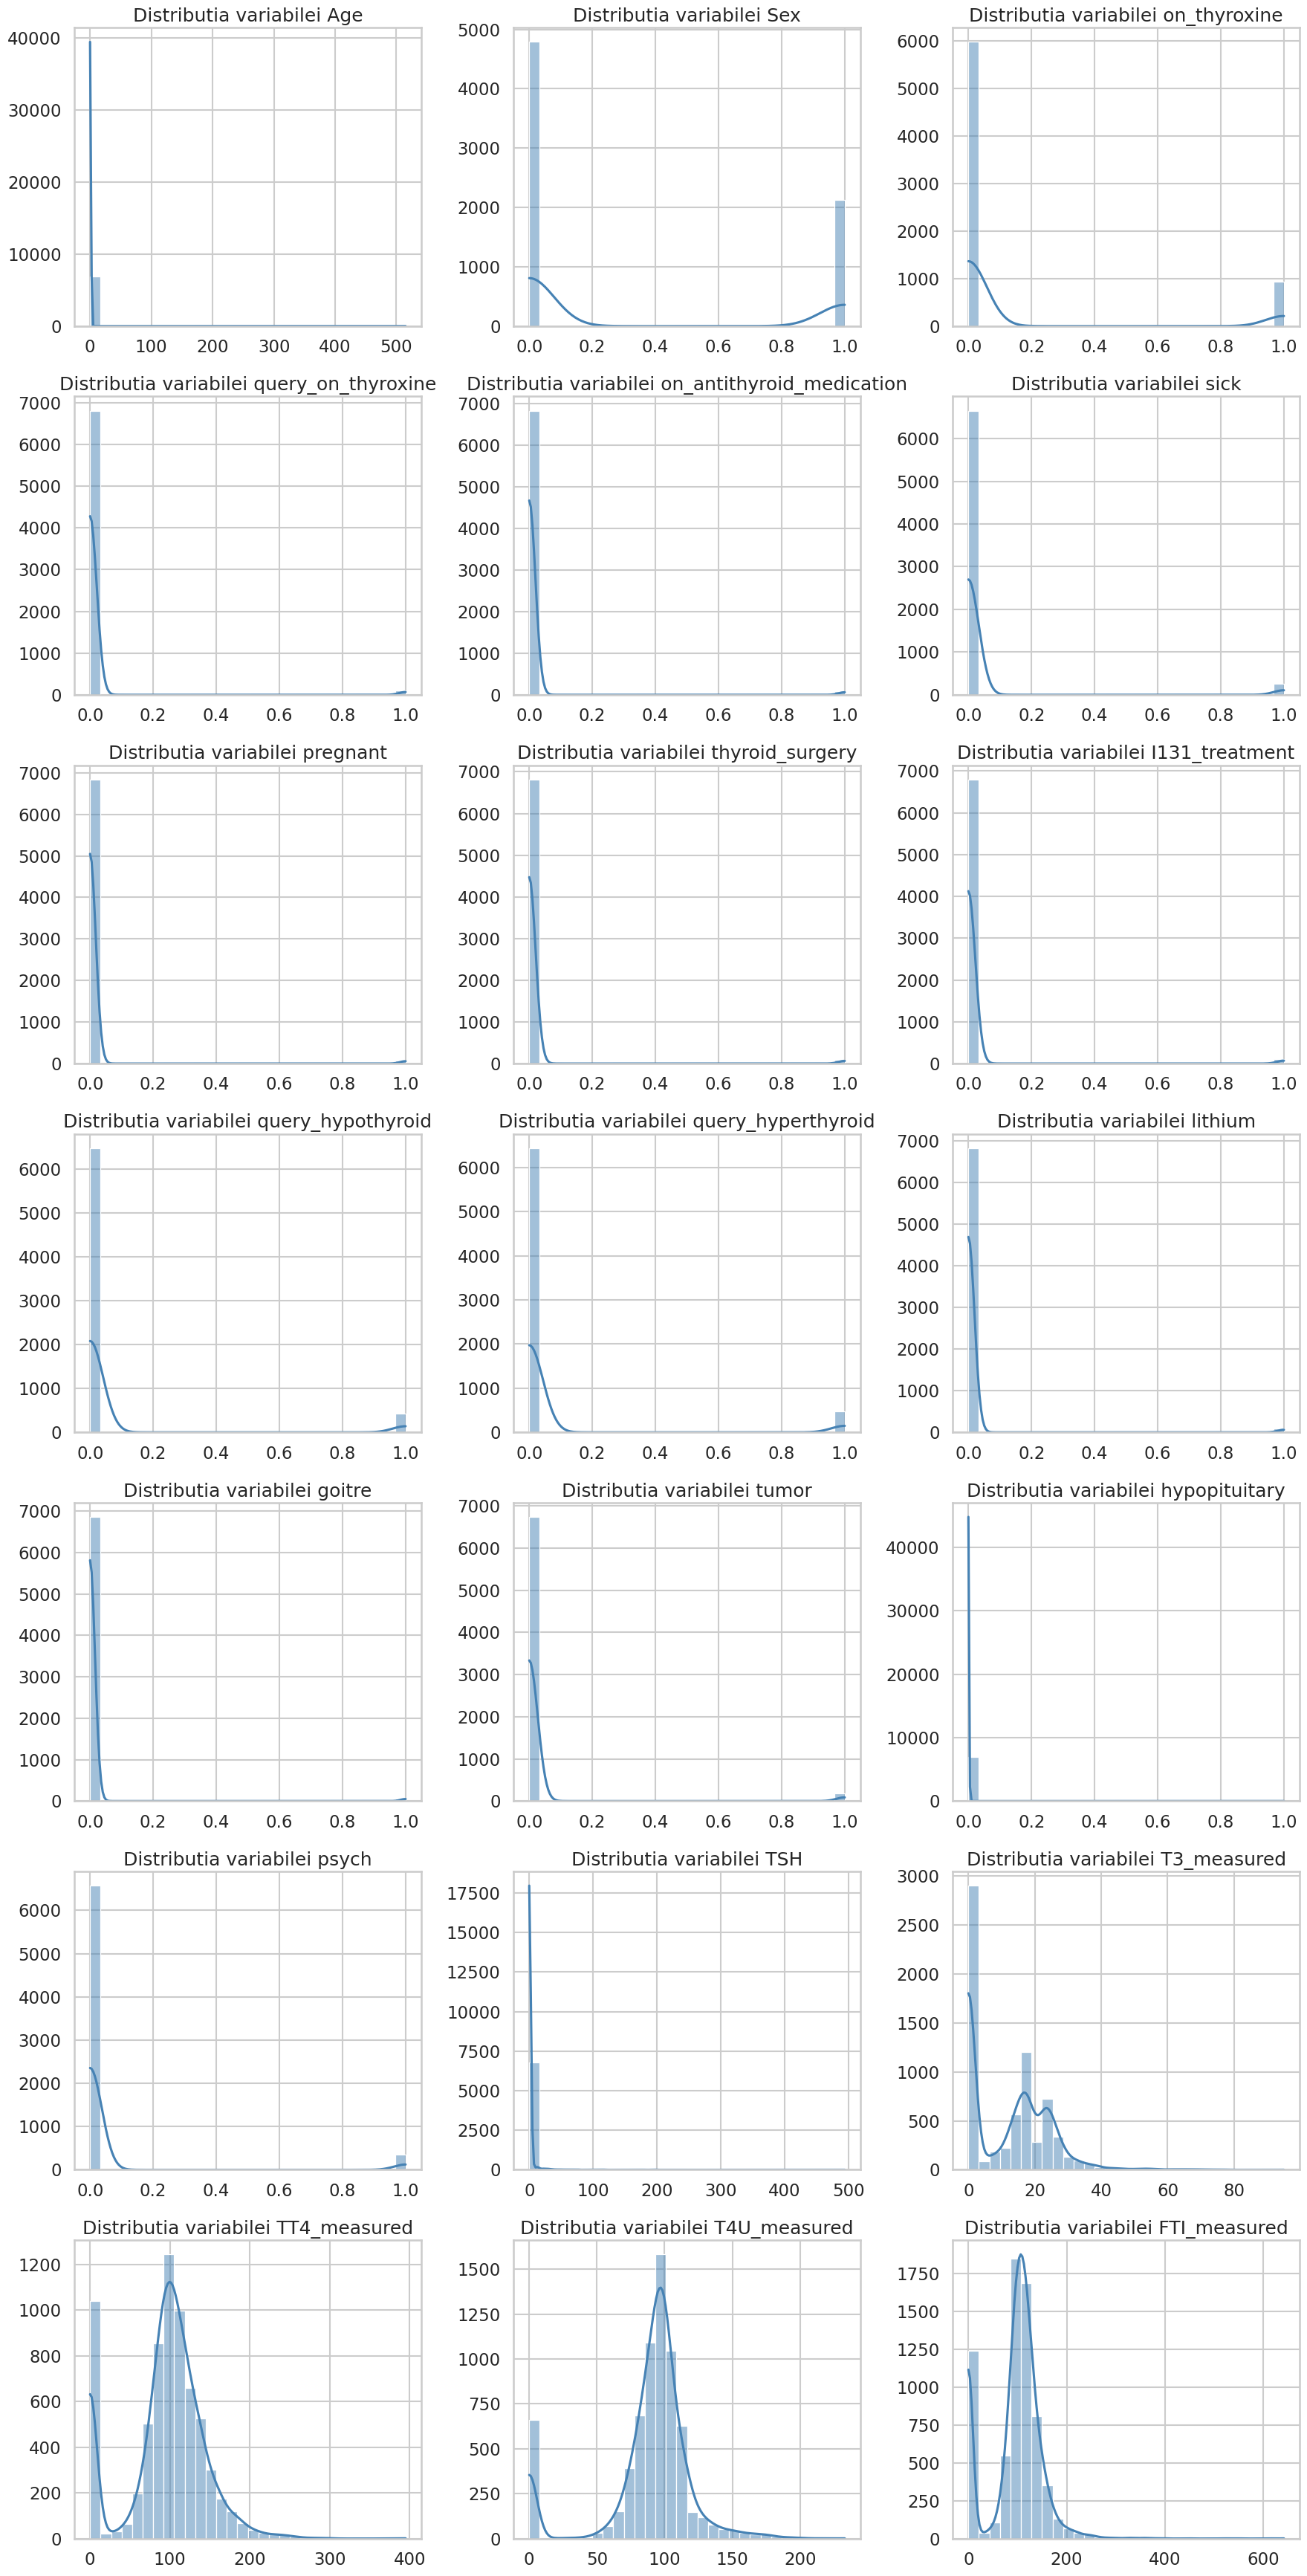

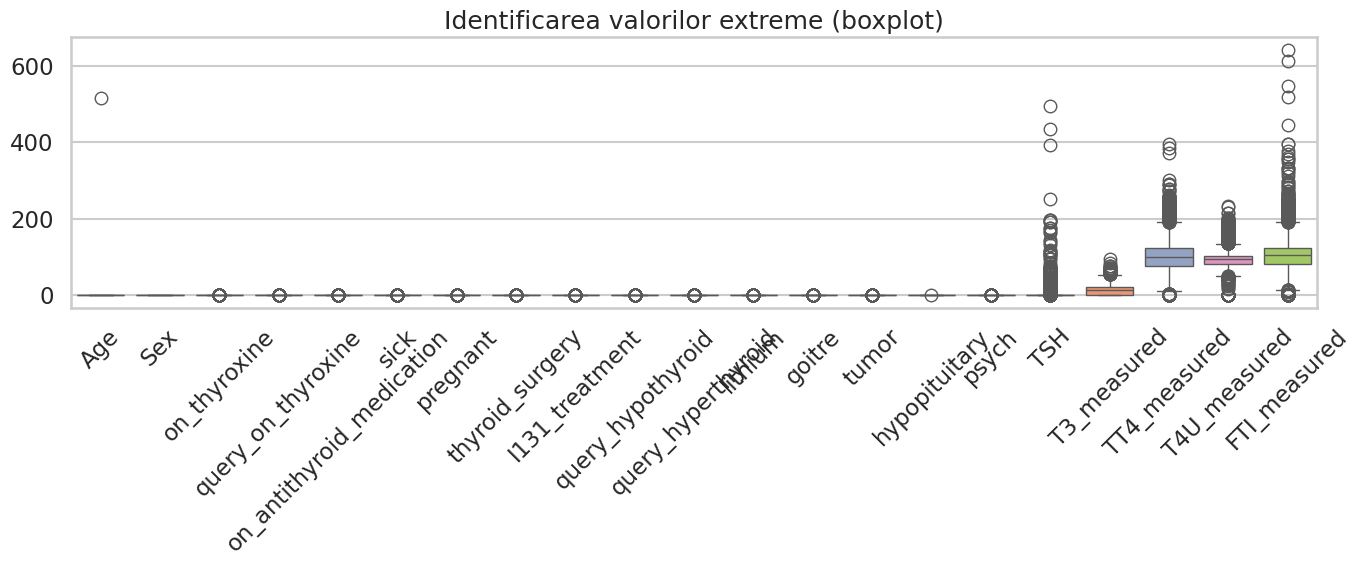

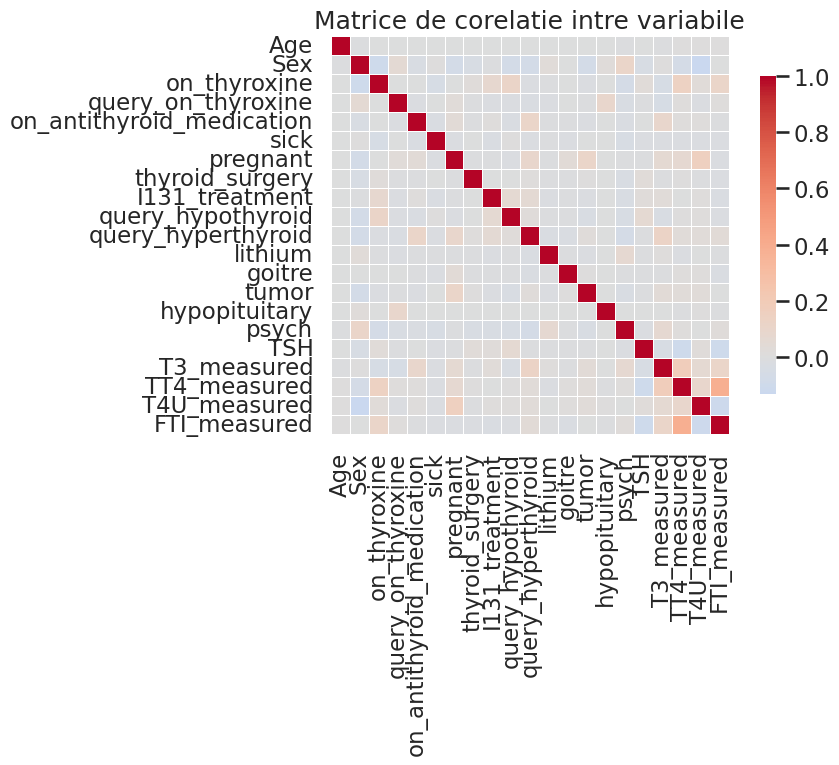

date normalizate:
                Age           Sex  on_thyroxine  query_on_thyroxine  \
count  6.916000e+03  6.916000e+03  6.916000e+03        6.916000e+03   
mean  -6.164338e-18 -6.472555e-17  1.849302e-17       -5.958860e-17   
std    1.000072e+00  1.000072e+00  1.000072e+00        1.000072e+00   
min   -9.454019e-02 -6.664404e-01 -3.944053e-01       -1.259511e-01   
25%   -3.637132e-02 -6.664404e-01 -3.944053e-01       -1.259511e-01   
50%   -8.902696e-03 -6.664404e-01 -3.944053e-01       -1.259511e-01   
75%    1.210273e-02  1.500509e+00 -3.944053e-01       -1.259511e-01   
max    8.311763e+01  1.500509e+00  2.535463e+00        7.939587e+00   

       on_antithyroid_medication          sick      pregnant  thyroid_surgery  \
count               6.916000e+03  6.916000e+03  6.916000e+03     6.916000e+03   
mean               -2.876691e-17  4.366406e-18 -4.109559e-17     4.674623e-17   
std                 1.000072e+00  1.000072e+00  1.000072e+00     1.000072e+00   
min               

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Curatare date

# stergem spatiile
df.columns = df.columns.str.strip()

#scoatem ce nu ne intereseaza
columns_to_drop = ["Unnamed: 22", "Unnamed: 23", "Outlier_label"]
df = df.drop(columns=columns_to_drop, errors="ignore")

# inlocuire valori lipsa simbolice
df = df.replace("?", np.nan)

# conversie defensiva la numeric (tot ce nu poate -> NaN)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# completare valori lipsa cu mediana
df = df.fillna(df.median())

print("valori lipsa dupa curatare:\n", df.isnull().sum())

# Explorare date

print(df.describe())

sns.set_theme(style="whitegrid", context="talk")

#Vizualizare date

num_cols_to_plot = len(df.columns)
num_cols_per_row = 3
num_rows_for_hist = (num_cols_to_plot + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows_for_hist, num_cols_per_row, figsize=(18, 5 * num_rows_for_hist))


if num_cols_to_plot == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"Distributia variabilei {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(num_cols_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df,
    palette="Set2",
    showfliers=True
)
plt.xticks(rotation=45)
plt.title("Identificarea valorilor extreme (boxplot)")
plt.tight_layout()
plt.show()

#Matrice de corelatie pe date alese

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de corelatie intre variabile")
plt.tight_layout()
plt.show()

#Normalizare
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("date normalizate:")
print(X_scaled.describe())

# Alegerea și aplicarea metodelor de detectare a anomaliilor

3. Metodele de detectare a anomaliilor utilizate

Pentru detectia anomaliilor au fost utilizate doua metode nesupravegheate din framework-ul PyOD:


*   K-Nearest Neighbors (KNN) – metoda bazata pe
distanta, care identifica anomaliile ca observatii aflate la distante mari fata de vecinii lor cei mai apropiati. Aceasta metoda este sensibila la structura locala a datelor si eficienta in detectarea observatiilor izolate.
*   Angle-Based Outlier Detection (ABOD) – metoda statistica ce detecteaza anomalii analizand variatia unghiurilor formate intre vectorii de date. ABOD este mai robusta in spatii de dimensiune mare si mai putin sensibila la densitatea locala, fiind potrivita pentru date complexe si nestructurate.


*   De asemenea, a fost testata metoda Lightweight Online Detector of Anomalies (LODA), utilizata pentru comparatie. In urma optimizarii parametrilor, LODA a obtinut un scor Silhouette de aproximativ 0.29, mai mic decat cel obtinut cu KNN si ABOD. Acest rezultat indica faptul ca anomaliile din setul de date sunt predominant locale, iar metodele bazate pe distante sau structura geometrica sunt mai potrivite decat cele bazate pe distributii globale.









shape dupa eliminare NaN: (6916, 21)
KNN – anomalii detectate: 320
ABOD – anomalii detectate: 337


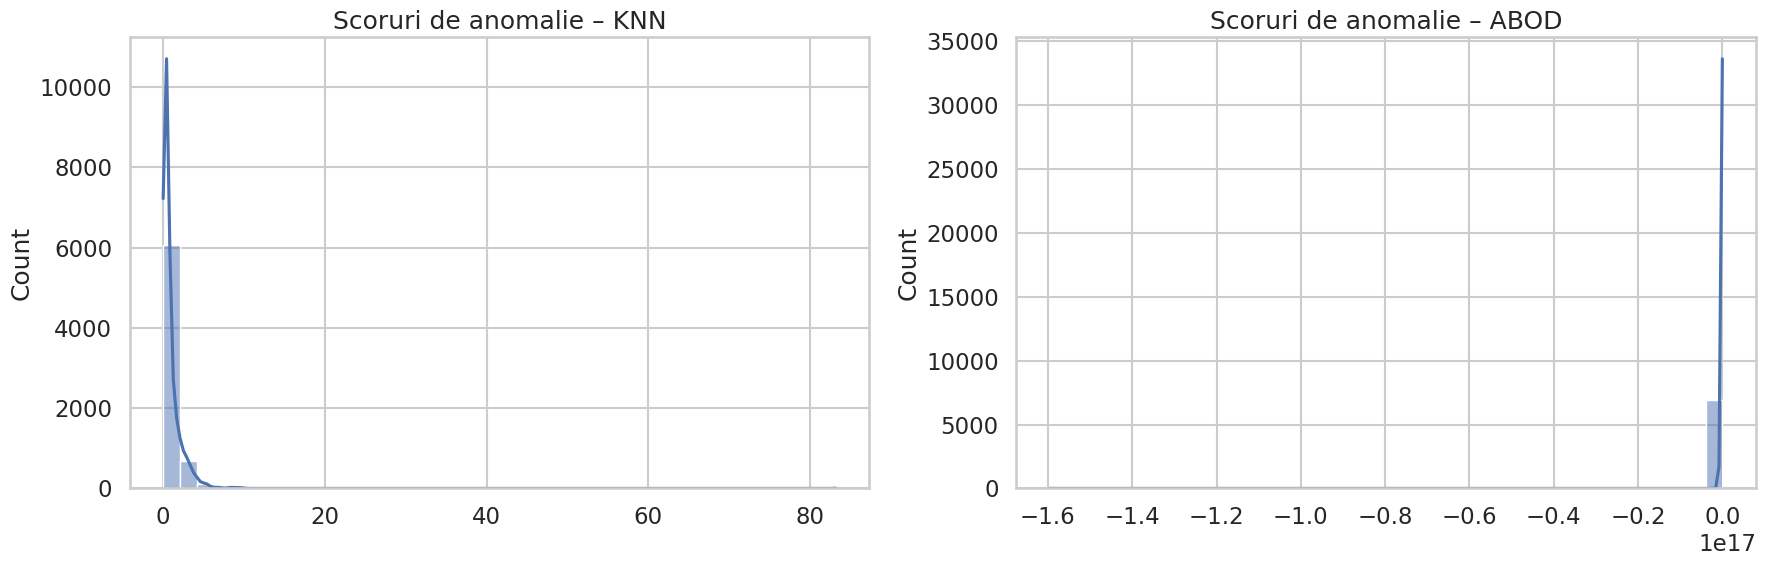

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyod.models.knn import KNN
from pyod.models.abod import ABOD

sns.set_theme(style="whitegrid", context="talk")

X = X_scaled.copy()

X = pd.DataFrame(X, columns=df.columns)

# eliminam orice rand care mai contine NaN
X = X.dropna()

print("shape dupa eliminare NaN:", X.shape)

X_np = X.values

# Model 1 – KNN (distance-based)
knn = KNN(
    n_neighbors=10,
    method="largest",
    contamination=0.05
)

knn.fit(X_np)

knn_scores = knn.decision_scores_
knn_labels = knn.predict(X_np)   # 1 = anomalie

# Model 2 – ABOD (statistical)
abod = ABOD(
    n_neighbors=20,
    contamination=0.05
)

abod.fit(X_np)

#Vizualizare rezultate

abod_scores = abod.decision_scores_
abod_labels = abod.predict(X_np)


print("KNN – anomalii detectate:", np.sum(knn_labels))
print("ABOD – anomalii detectate:", np.sum(abod_labels))


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(knn_scores, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Scoruri de anomalie – KNN")

sns.histplot(abod_scores, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Scoruri de anomalie – ABOD")

plt.tight_layout()
plt.show()

scores_df = pd.DataFrame({
    "KNN": knn_scores,
    "ABOD": abod_scores
})


# Optimizare

In [39]:
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
import numpy as np

knn_neighbors = [5, 10, 20]
contaminations = [0.03, 0.05, 0.1]
knn_methods = ["largest", "mean"]

print("Optimizare KNN")
for k in knn_neighbors:
    for c in contaminations:
        for m in knn_methods:
            knn = KNN(
                n_neighbors=k,
                contamination=c,
                method=m
            )
            knn.fit(X_np)
            n_outliers = np.sum(knn.predict(X_np))
            print(f"KNN | k={k:2d} | cont={c:.2f} | method={m:7s} -> outliers={n_outliers}")

print("\n=== Optimizare ABOD ===")
abod_neighbors = [10, 20, 30]

for k in abod_neighbors:
    for c in contaminations:
        abod = ABOD(
            n_neighbors=k,
            contamination=c
        )
        abod.fit(X_np)
        n_outliers = np.sum(abod.predict(X_np))
        print(f"ABOD | k={k:2d} | cont={c:.2f} -> outliers={n_outliers}")


=== OPTIMIZARE KNN ===
KNN | k= 5 | cont=0.03 | method=largest -> outliers=188
KNN | k= 5 | cont=0.03 | method=mean    -> outliers=103
KNN | k= 5 | cont=0.05 | method=largest -> outliers=299
KNN | k= 5 | cont=0.05 | method=mean    -> outliers=189
KNN | k= 5 | cont=0.10 | method=largest -> outliers=610
KNN | k= 5 | cont=0.10 | method=mean    -> outliers=429
KNN | k=10 | cont=0.03 | method=largest -> outliers=190
KNN | k=10 | cont=0.03 | method=mean    -> outliers=148
KNN | k=10 | cont=0.05 | method=largest -> outliers=320
KNN | k=10 | cont=0.05 | method=mean    -> outliers=250
KNN | k=10 | cont=0.10 | method=largest -> outliers=669
KNN | k=10 | cont=0.10 | method=mean    -> outliers=539
KNN | k=20 | cont=0.03 | method=largest -> outliers=199
KNN | k=20 | cont=0.03 | method=mean    -> outliers=171
KNN | k=20 | cont=0.05 | method=largest -> outliers=339
KNN | k=20 | cont=0.05 | method=mean    -> outliers=292
KNN | k=20 | cont=0.10 | method=largest -> outliers=677
KNN | k=20 | cont=0.10 | 

4. Implementarea metodelor si ajustarile efectuate

Ambele metode au fost implementate folosind aceeasi structura modulara oferita de PyOD, ceea ce a permis compararea directa a rezultatelor. Parametrii au fost ajustati experimental pentru a obtine un echilibru intre sensibilitate si stabilitate.

Pentru KNN au fost testate diferite valori ale numarului de vecini (n_neighbors), metode de calcul al distantei (largest, mean) si valori ale parametrului contamination. S-a observat ca valori prea mici pentru numarul de vecini conduc la supradetectia anomaliilor, in timp ce valori prea mari reduc sensibilitatea. O configuratie intermediara a oferit rezultate echilibrate.

Pentru ABOD, parametrul principal ajustat a fost n_neighbors, deoarece acesta influenteaza stabilitatea estimarii unghiulare. Valorile prea mici au produs scoruri instabile, iar valori mai mari au dus la rezultate mai robuste.


# Evaluarea performantei

5. Evaluarea performantei si interpretarea rezultatelor

Performanta metodelor a fost evaluata folosind metrici nesupravegheate, adecvate pentru detectia anomaliilor in absenta etichetelor reale. Au fost utilizate urmatoarele metrici:

Silhouette score, pentru a evalua separarea dintre observatiile normale si cele detectate ca anomalii;

Rezultatele au aratat valori ale Silhouette score in jur de 0.5 pentru ambele metode, indicand o separare moderata, dar realista, intre observatii. Diferentele intre metode reflecta natura distincta a acestora: KNN este mai sensibil la distante locale, iar ABOD ofera o detectie mai stabila din punct de vedere geometric.

Vizualizarea rezultatelor folosind PCA in doua dimensiuni a evidentiat faptul ca anomaliile sunt situate preponderent la marginile distributiei principale, fara a forma structuri bine delimitate, ceea ce confirma corectitudinea abordarii nesupravegheate.


In [56]:
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

sil_knn = silhouette_score(X_np, knn_labels)

sil_abod = silhouette_score(X_np, abod_labels)

print("=== KNN ===")
print(f"Silhouette score : {sil_knn:.4f}")

print("\n=== ABOD ===")
print(f"Silhouette score : {sil_abod:.4f}")

=== KNN ===
Silhouette score : 0.5117

=== ABOD ===
Silhouette score : 0.4942


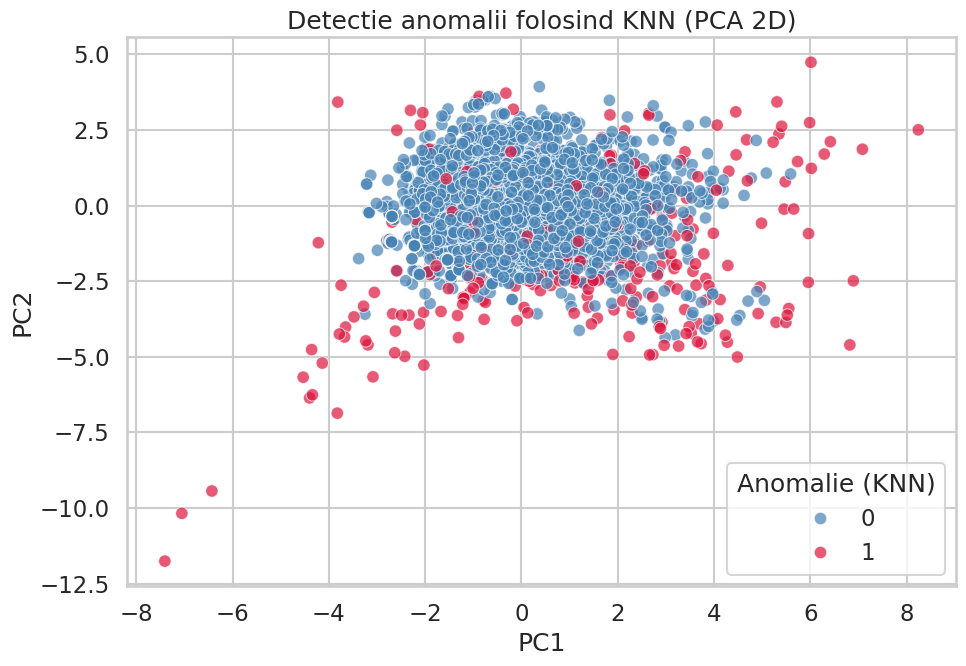

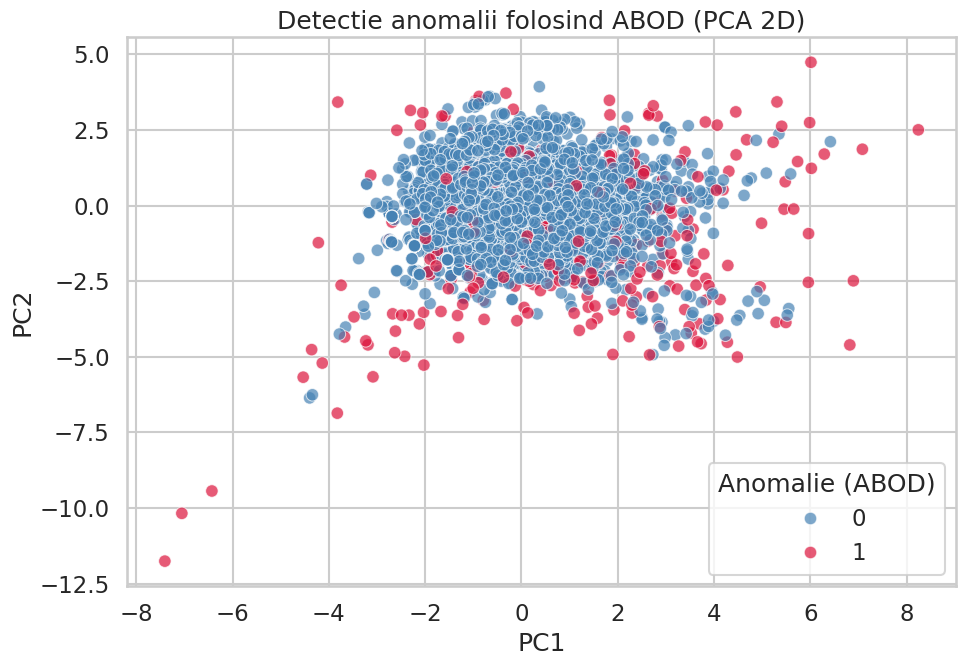

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

# PCA 2D

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["KNN"] = knn_labels
pca_df["ABOD"] = abod_labels

# VIZUALIZARE KNN

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KNN",
    palette={0: "steelblue", 1: "crimson"},
    alpha=0.7
)
plt.title("Detectie anomalii folosind KNN (PCA 2D)")
plt.legend(title="Anomalie (KNN)")
plt.tight_layout()
plt.show()

# VIZUALIZARE ABOD

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="ABOD",
    palette={0: "steelblue", 1: "crimson"},
    alpha=0.7
)
plt.title("Detectie anomalii folosind ABOD (PCA 2D)")
plt.legend(title="Anomalie (ABOD)")
plt.tight_layout()
plt.show()


Compararea metodelor evidentiaza faptul ca performanta depinde in mod direct de natura anomaliilor din setul de date. KNN a oferit cele mai bune rezultate datorita sensibilitatii sale la structura locala a datelor. ABOD a avut performante apropiate, confirmand existenta unor relatii geometrice relevante intre observatii. LODA, desi eficienta din punct de vedere computational, nu s-a adaptat la caracterul local al anomaliilor si a obtinut rezultate inferioare.

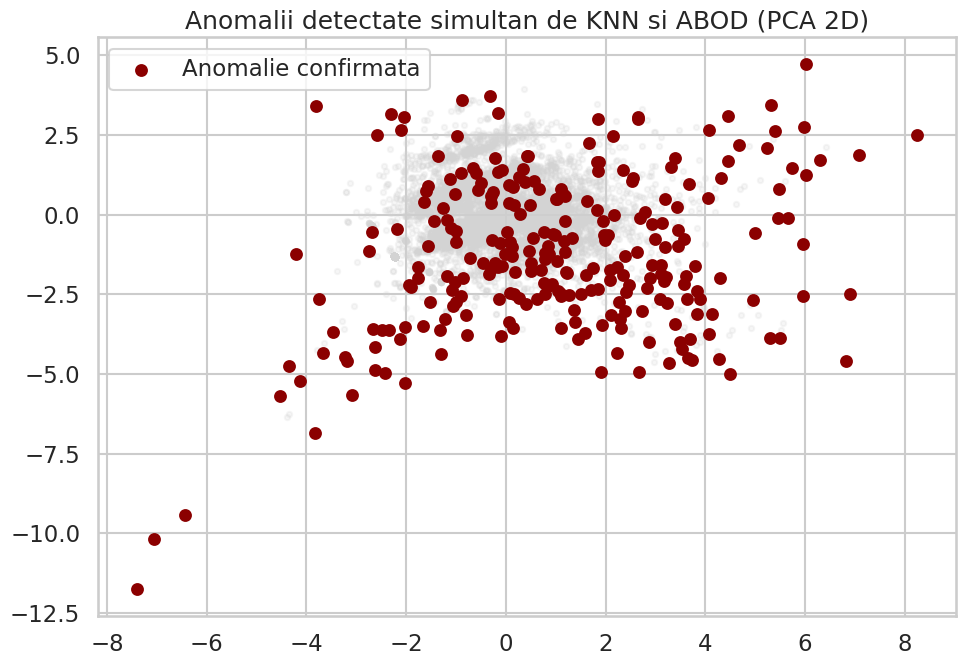

In [43]:
pca_df["COMMON"] = (pca_df["KNN"] == 1) & (pca_df["ABOD"] == 1)

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"], pca_df["PC2"],
    c="lightgray", alpha=0.2, s=15
)

plt.scatter(
    pca_df.loc[pca_df["COMMON"], "PC1"],
    pca_df.loc[pca_df["COMMON"], "PC2"],
    c="darkred", s=60, label="Anomalie confirmata"
)

plt.title("Anomalii detectate simultan de KNN si ABOD (PCA 2D)")
plt.legend()
plt.tight_layout()
plt.show()


Concluzii

In acest proiect a fost realizata detectia anomaliilor intr-un set de date medicale utilizand metode nesupravegheate din framework-ul PyOD. Rezultatele obtinute sunt consistente cu natura datelor si demonstreaza ca metodele bazate pe distanta si cele statistice pot identifica observatii atipice fara a necesita etichete. Analiza comparativa a evidentiat avantajele si limitarile fiecarei metode, iar pipeline-ul modular permite extinderea usoara cu alte tehnici de detectie.


Bibliografie

[1] F. Zhongli, “Thyroid Disease – Unsupervised Anomaly Detection Dataset,” Kaggle, 2023. [Online]. Available: https://www.kaggle.com/datasets/zhonglifr/thyroid-disease-unsupervised-anomaly-detection.

[2] “k-NNN: Nearest Neighbors of Neighbors for Anomaly Detection,” ResearchGate, [Online]. Available: https://www.researchgate.net/publication/371136371_k-NNN_Nearest_Neighbors_of_Neighbors_for_Anomaly_Detection.
